# Marchenko-Pastur Covariance Denoising

This notebook implements Lopez de Prado-style Marchenko-Pastur covariance denoising for the existing 10-stock sleeve framework and compares it against the project's covariance benchmarks.

The method denoises the sample correlation matrix by replacing eigenvalues inside the Marchenko-Pastur noise band with their average, converts the denoised correlation back to covariance using the original sample volatilities, and feeds that covariance into the existing long-only GMV optimizer.

## Experimental Setup

| Item | Setting |
|---|---|
| Data | CRSP daily equities |
| Universe | Dynamic market-cap top 500 |
| Sleeve size | 10 same-industry stocks |
| Lookback | 126 trading days |
| Holding period | 21 trading days |
| Train | 2000-2013 |
| Validation | 2014-2020 |
| Test | 2021-2025 |
| Portfolio | Long-only minimum variance |
| Sleeve aggregation | Equal capital across active sleeves |

There is no model training or hyperparameter tuning here. The validation period is reported as a diagnostic comparison; final emphasis remains the 2021-2025 test comparison.

In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import run_one_rebalance
from src.benchmarks import equal_weight, ledoit_wolf_linear_gmv
from src.covariance import build_covariance_pair
from src.gmv import solve_long_only_gmv
from src.groups import get_sleeve_permnos
from src.metrics import (
    annualized_return,
    annualized_volatility,
    cvar_95,
    maximum_drawdown,
    sharpe_ratio,
    volatility_reduction_vs_sample_gmv,
)
from src.turnover import apply_transaction_costs

pd.set_option("display.max_columns", 100)

SMOKE_TEST = os.environ.get("MP_PDF_SMOKE_TEST", "0") == "1"
SAVE_RESULTS = not SMOKE_TEST
LOOKBACK_DAYS = 126
HORIZON_DAYS = 21
SLEEVE_SIZE = 10
TRANSACTION_COST_BPS = 10.0
N_OBS = LOOKBACK_DAYS
N_ASSETS = SLEEVE_SIZE
Q = N_OBS / N_ASSETS
RESULTS_DIR = PROJECT_ROOT / "results" / "mp_pdf"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Smoke test:", SMOKE_TEST)
print("q =", Q)

Smoke test: False
q = 12.6


## Marchenko-Pastur Denoising Functions

For this project, `T = 126`, `N = 10`, and therefore `q = T / N = 12.6`. With `sigma2 = 1`, the upper Marchenko-Pastur noise bound is:

\[
\lambda_+ = (1 + \sqrt{1/q})^2
\]

Eigenvalues above `lambda_plus` are treated as signal. Eigenvalues at or below `lambda_plus` are treated as noise and replaced by their average.

In [3]:
def cov_to_corr(cov: np.ndarray) -> np.ndarray:
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    denom = np.outer(std, std)
    corr = np.divide(cov, denom, out=np.zeros_like(cov, dtype=float), where=denom > 0)
    corr = 0.5 * (corr + corr.T)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def corr_to_cov(corr: np.ndarray, std: np.ndarray) -> np.ndarray:
    corr = np.asarray(corr, dtype=float)
    std = np.asarray(std, dtype=float)
    cov = corr * np.outer(std, std)
    return 0.5 * (cov + cov.T)


def marchenko_pastur_lambda_plus(q: float, sigma2: float = 1.0) -> float:
    if q <= 0:
        raise ValueError(f"q must be positive, got {q}")
    if sigma2 <= 0:
        raise ValueError(f"sigma2 must be positive, got {sigma2}")
    return float(sigma2 * (1.0 + np.sqrt(1.0 / q)) ** 2)


def denoise_corr_mp(corr: np.ndarray, q: float, sigma2: float = 1.0) -> np.ndarray:
    corr = np.asarray(corr, dtype=float)
    corr = 0.5 * (corr + corr.T)
    np.fill_diagonal(corr, 1.0)

    eigvals, eigvecs = np.linalg.eigh(corr)
    eigvals = np.maximum(eigvals, 0.0)
    lambda_plus = marchenko_pastur_lambda_plus(q, sigma2=sigma2)
    noise_mask = eigvals <= lambda_plus

    eigvals_denoised = eigvals.copy()
    if np.any(noise_mask):
        eigvals_denoised[noise_mask] = eigvals[noise_mask].mean()

    corr_denoised = eigvecs @ np.diag(eigvals_denoised) @ eigvecs.T
    corr_denoised = 0.5 * (corr_denoised + corr_denoised.T)

    # Re-normalize to a proper correlation matrix after reconstruction.
    diag = np.sqrt(np.clip(np.diag(corr_denoised), 1e-12, None))
    corr_denoised = corr_denoised / np.outer(diag, diag)
    corr_denoised = 0.5 * (corr_denoised + corr_denoised.T)
    corr_denoised = np.clip(corr_denoised, -1.0, 1.0)
    np.fill_diagonal(corr_denoised, 1.0)
    return corr_denoised


def denoise_cov_mp(cov: np.ndarray, n_obs: int = 126, sigma2: float = 1.0) -> np.ndarray:
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    n_assets = cov.shape[0]
    if cov.shape[0] != cov.shape[1]:
        raise ValueError(f"cov must be square, got {cov.shape}")
    q = float(n_obs) / float(n_assets)
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    corr = cov_to_corr(cov)
    corr_denoised = denoise_corr_mp(corr, q=q, sigma2=sigma2)
    return corr_to_cov(corr_denoised, std)

# Required function checks
lambda_plus = marchenko_pastur_lambda_plus(Q)
print("MP lambda_plus:", lambda_plus)
assert np.isclose(lambda_plus, (1 + np.sqrt(1 / 12.6)) ** 2)
assert cov_to_corr(np.eye(10)).shape == (10, 10)
assert denoise_cov_mp(np.eye(10), n_obs=126).shape == (10, 10)
assert np.allclose(np.diag(denoise_corr_mp(np.eye(10), q=Q)), 1.0)

MP lambda_plus: 1.6428012491840904


## Load Existing Pipeline Data

In [4]:
def load_backtest_inputs():
    interim = PROJECT_ROOT / "data" / "interim"
    crsp = pd.read_parquet(interim / "cleaned_crsp_daily.parquet")
    crsp["date"] = pd.to_datetime(crsp["date"])

    cal = pd.read_parquet(interim / "trading_calendar.parquet")
    trading_dates = pd.DatetimeIndex(pd.to_datetime(cal["date"]).sort_values())

    reb = pd.read_parquet(interim / "rebalance_dates.parquet")
    reb["rebalance_date"] = pd.to_datetime(reb["rebalance_date"])

    sleeves = pd.read_parquet(interim / "evaluation_sleeves.parquet")
    sleeves["rebalance_date"] = pd.to_datetime(sleeves["rebalance_date"])
    return crsp, trading_dates, reb, sleeves

crsp_df, trading_dates, rebalance_df, evaluation_sleeves = load_backtest_inputs()
val_dates = sorted(rebalance_df.loc[rebalance_df["split"] == "validation", "rebalance_date"].tolist())
test_dates = sorted(rebalance_df.loc[rebalance_df["split"] == "test", "rebalance_date"].tolist())

if SMOKE_TEST:
    val_dates = val_dates[:2]
    test_dates = test_dates[:2]

print("Validation dates:", len(val_dates), val_dates[0], val_dates[-1])
print("Test dates:", len(test_dates), test_dates[0], test_dates[-1])
print("Evaluation sleeves:", evaluation_sleeves.shape)

Validation dates: 83 2013-12-31 00:00:00 2020-11-02 00:00:00
Test dates: 47 2020-12-31 00:00:00 2024-11-04 00:00:00
Evaluation sleeves: (39450, 6)


## Precompute Sleeve Covariances

In [5]:
def precompute_sleeve_data(dates: List[pd.Timestamp]) -> Dict[Tuple[pd.Timestamp, int], Dict]:
    out = {}
    for date in dates:
        date_sleeves = evaluation_sleeves[evaluation_sleeves["rebalance_date"] == date]
        for sid in date_sleeves["sleeve_id"].unique():
            permnos = get_sleeve_permnos(date_sleeves, sid)
            result = build_covariance_pair(
                crsp_df,
                trading_dates,
                permnos,
                date,
                lookback_days=LOOKBACK_DAYS,
                horizon_days=HORIZON_DAYS,
            )
            if result is None:
                continue
            S_hist, S_fwd, R_hist, R_fwd = result
            out[(date, int(sid))] = {
                "permnos": permnos,
                "S_hist": S_hist,
                "S_fwd": S_fwd,
                "R_hist": R_hist,
                "R_fwd": R_fwd,
            }
    return out

val_sleeve_data = precompute_sleeve_data(val_dates)
test_sleeve_data = precompute_sleeve_data(test_dates)
print("Validation sleeve-date observations:", len(val_sleeve_data))
print("Test sleeve-date observations:", len(test_sleeve_data))

Validation sleeve-date observations: 2425
Test sleeve-date observations: 1434


## Benchmark And Backtest Utilities

In [6]:
def ewma_covariance(return_matrix: np.ndarray, lam: float = 0.94) -> np.ndarray:
    R = np.asarray(return_matrix, dtype=float)
    R = R - R.mean(axis=0, keepdims=True)
    T = R.shape[0]
    weights = np.array([(1 - lam) * lam ** (T - 1 - i) for i in range(T)], dtype=float)
    weights = weights / weights.sum()
    cov = (R * weights[:, None]).T @ R
    return 0.5 * (cov + cov.T)


def make_weight_fn(sleeve_data: Dict[Tuple[pd.Timestamp, int], Dict], method: str):
    def fn(date: pd.Timestamp):
        date_sleeves = evaluation_sleeves[evaluation_sleeves["rebalance_date"] == date]
        sleeve_wts, sleeve_perms = {}, {}
        for sid in date_sleeves["sleeve_id"].unique():
            key = (date, int(sid))
            if key not in sleeve_data:
                continue
            data = sleeve_data[key]
            if method == "equal_weight":
                w = equal_weight(len(data["permnos"]))
            elif method == "sample_covariance_gmv":
                w = solve_long_only_gmv(data["S_hist"])
            elif method == "ledoit_wolf_gmv":
                w = ledoit_wolf_linear_gmv(data["R_hist"])
            elif method == "ewma_gmv":
                w = solve_long_only_gmv(ewma_covariance(data["R_hist"]))
            elif method == "mp_pdf_gmv":
                cov_mp = denoise_cov_mp(data["S_hist"], n_obs=LOOKBACK_DAYS, sigma2=1.0)
                w = solve_long_only_gmv(cov_mp)
            else:
                raise ValueError(method)
            sleeve_wts[int(sid)] = w
            sleeve_perms[int(sid)] = data["permnos"]
        return sleeve_wts, sleeve_perms
    return fn


def run_method_backtest(method_name: str, dates: List[pd.Timestamp], sleeve_data: Dict, method: str, cost_bps: float = TRANSACTION_COST_BPS) -> Dict:
    weight_fn = make_weight_fn(sleeve_data, method)
    all_gross, all_weights, all_turnovers, rebalance_indices = [], [], [], []
    previous_drifted = None

    for date in dates:
        sleeve_wts, sleeve_perms = weight_fn(date)
        if not sleeve_wts:
            continue
        daily_rets, agg_wts, drifted, turnover = run_one_rebalance(
            sleeve_weights=sleeve_wts,
            sleeve_permnos=sleeve_perms,
            crsp_df=crsp_df,
            trading_dates=trading_dates,
            rebalance_date=date,
            horizon_days=HORIZON_DAYS,
            previous_drifted_weights=previous_drifted,
        )
        if not daily_rets:
            continue
        assert abs(sum(agg_wts.values()) - 1.0) < 1e-6
        rebalance_indices.append(len(all_gross))
        all_gross.extend(daily_rets)
        all_weights.append((date, agg_wts))
        all_turnovers.append((date, turnover))
        previous_drifted = drifted

    net = apply_transaction_costs(
        all_gross,
        rebalance_indices,
        [x[1] for x in all_turnovers],
        cost_bps=cost_bps,
    )
    return {
        "method": method_name,
        "gross_returns": all_gross,
        "net_returns": net,
        "weights": all_weights,
        "turnovers": all_turnovers,
        "rebalance_indices": rebalance_indices,
    }

methods = {
    "Equal_Weight": "equal_weight",
    "Sample_Covariance_GMV": "sample_covariance_gmv",
    "LedoitWolf_Linear_GMV": "ledoit_wolf_gmv",
    "EWMA_GMV": "ewma_gmv",
    "MP_PDF_Denoised_GMV": "mp_pdf_gmv",
}

In [7]:
def weights_to_array_list(weights_records: List[Tuple[pd.Timestamp, Dict[int, float]]]) -> List[np.ndarray]:
    return [np.asarray(list(w.values()), dtype=float) for _, w in weights_records]


def summarize_backtest(name: str, bt: Dict, sample_vol: Optional[float] = None) -> Dict:
    gross = np.asarray(bt["gross_returns"], dtype=float)
    net = np.asarray(bt["net_returns"], dtype=float)
    weight_arrays = weights_to_array_list(bt["weights"])
    hhis = [float(np.sum(w ** 2)) for w in weight_arrays]
    max_weights = [float(np.max(w)) for w in weight_arrays]
    turnovers = [x[1] for x in bt["turnovers"]]
    vol = annualized_volatility(gross)
    return {
        "method": name,
        "annualized_volatility": vol,
        "volatility_reduction_vs_sample_cov_mv": np.nan if sample_vol is None else volatility_reduction_vs_sample_gmv(vol, sample_vol),
        "annualized_return": annualized_return(gross),
        "sharpe_ratio": sharpe_ratio(gross),
        "cvar_95": cvar_95(gross),
        "maximum_drawdown": maximum_drawdown(gross),
        "average_turnover": float(np.mean(turnovers)) if turnovers else np.nan,
        "average_hhi": float(np.mean(hhis)) if hhis else np.nan,
        "average_max_weight": float(np.mean(max_weights)) if max_weights else np.nan,
        "net_return_after_transaction_costs": annualized_return(net),
        "n_daily_returns": len(gross),
        "n_rebalances": len(bt["weights"]),
    }


def run_suite(dates: List[pd.Timestamp], sleeve_data: Dict) -> Tuple[Dict[str, Dict], pd.DataFrame]:
    backtests = {}
    for label, method in methods.items():
        print("Running", label)
        backtests[label] = run_method_backtest(label, dates, sleeve_data, method)
    sample_vol = annualized_volatility(backtests["Sample_Covariance_GMV"]["gross_returns"])
    summary = pd.DataFrame(
        [summarize_backtest(name, bt, sample_vol) for name, bt in backtests.items()]
    ).sort_values("annualized_volatility")
    return backtests, summary

## Validation Comparison

In [8]:
validation_backtests, validation_summary = run_suite(val_dates, val_sleeve_data)
display(validation_summary)
if SAVE_RESULTS:
    validation_summary.to_csv(RESULTS_DIR / "validation_comparison_summary.csv", index=False)

Running Equal_Weight
Running Sample_Covariance_GMV
Running LedoitWolf_Linear_GMV
Running EWMA_GMV
Running MP_PDF_Denoised_GMV


,method,annualized_volatility,volatility_reduction_vs_sample_cov_mv,annualized_return,sharpe_ratio,cvar_95,maximum_drawdown,average_turnover,average_hhi,average_max_weight,net_return_after_transaction_costs,n_daily_returns,n_rebalances
3,EWMA_GMV,0.159426,0.004657,0.120580,0.794643,0.024545,-0.334293,0.904347,0.012020,0.029816,0.108502,1743,83
4,MP_PDF_Denoised_GMV,0.159623,0.003426,0.117750,0.777856,0.024642,-0.343664,0.435566,0.010263,0.027695,0.111936,1743,83
1,Sample_Covariance_GMV,0.160172,0.000000,0.115010,0.760464,0.024785,-0.345328,0.475574,0.010613,0.028493,0.108679,1743,83
2,LedoitWolf_Linear_GMV,0.163114,-0.018366,0.118286,0.767656,0.025239,-0.346265,0.424856,0.008010,0.022557,0.112611,1743,83
0,Equal_Weight,0.180817,-0.128895,0.142146,0.826096,0.028062,-0.347446,0.210018,0.003438,0.003438,0.139277,1743,83


## Final Test Comparison

In [9]:
test_backtests, test_summary = run_suite(test_dates, test_sleeve_data)
display(test_summary)
if SAVE_RESULTS:
    test_summary.to_csv(RESULTS_DIR / "test_comparison_summary.csv", index=False)

Running Equal_Weight
Running Sample_Covariance_GMV
Running LedoitWolf_Linear_GMV
Running EWMA_GMV
Running MP_PDF_Denoised_GMV


,method,annualized_volatility,volatility_reduction_vs_sample_cov_mv,annualized_return,sharpe_ratio,cvar_95,maximum_drawdown,average_turnover,average_hhi,average_max_weight,net_return_after_transaction_costs,n_daily_returns,n_rebalances
3,EWMA_GMV,0.126853,0.003987,0.111018,0.893499,0.018141,-0.183312,0.835998,0.011497,0.028133,0.099939,987,47
1,Sample_Covariance_GMV,0.127361,0.000000,0.105531,0.851553,0.018028,-0.190794,0.436709,0.010348,0.026479,0.099757,987,47
4,MP_PDF_Denoised_GMV,0.127651,-0.002276,0.103405,0.834815,0.018027,-0.195754,0.387878,0.009954,0.025918,0.098284,987,47
2,LedoitWolf_Linear_GMV,0.131035,-0.028848,0.106528,0.838177,0.018497,-0.197495,0.386479,0.007990,0.021468,0.101411,987,47
0,Equal_Weight,0.173684,-0.363715,0.103232,0.652560,0.024655,-0.256274,0.171447,0.003283,0.003283,0.100962,987,47


## Existing Diffusion Results, If Available

In [ ]:
existing_summary_path = PROJECT_ROOT / "results" / "test" / "test_performance_summary.csv"
if existing_summary_path.exists():
    existing = pd.read_csv(existing_summary_path)
    display(existing)
else:
    print("No existing results/test/test_performance_summary.csv found; diffusion comparison table is skipped.")

## Eigenvalue Diagnostics

In [ ]:
def collect_mp_diagnostics(sleeve_data: Dict) -> pd.DataFrame:
    rows = []
    lambda_plus = marchenko_pastur_lambda_plus(Q)
    for (date, sid), data in sleeve_data.items():
        corr = cov_to_corr(data["S_hist"])
        eigvals = np.linalg.eigvalsh(corr)
        rows.append({
            "rebalance_date": date,
            "sleeve_id": sid,
            "lambda_plus": lambda_plus,
            "n_signal_eigenvalues": int(np.sum(eigvals > lambda_plus)),
            "max_eigenvalue": float(eigvals.max()),
            "min_eigenvalue": float(eigvals.min()),
            "mean_noise_eigenvalue": float(eigvals[eigvals <= lambda_plus].mean()) if np.any(eigvals <= lambda_plus) else np.nan,
        })
    return pd.DataFrame(rows)

test_mp_diag = collect_mp_diagnostics(test_sleeve_data)
display(test_mp_diag.describe(include="all"))
if SAVE_RESULTS:
    test_mp_diag.to_csv(RESULTS_DIR / "test_mp_eigen_diagnostics.csv", index=False)

## Plots

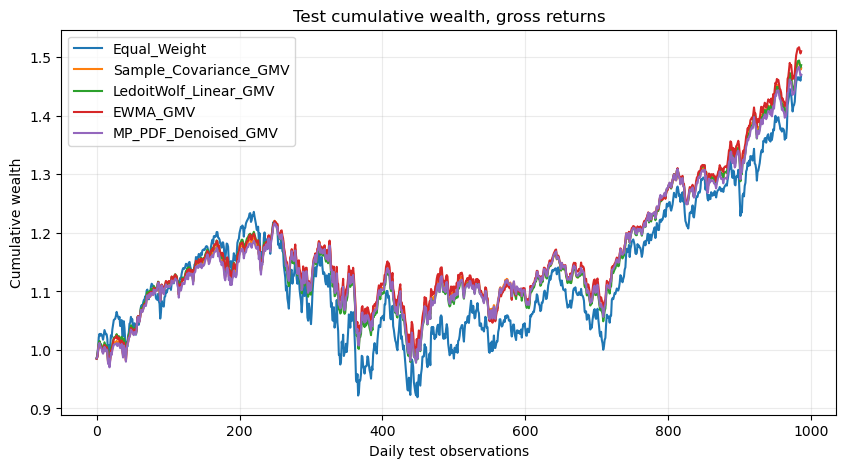

In [10]:
def wealth_series(returns):
    return np.cumprod(1 + np.asarray(returns, dtype=float))

fig, ax = plt.subplots(figsize=(10, 5))
for name, bt in test_backtests.items():
    ax.plot(wealth_series(bt["gross_returns"]), label=name)
ax.set_title("Test cumulative wealth, gross returns")
ax.set_xlabel("Daily test observations")
ax.set_ylabel("Cumulative wealth")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

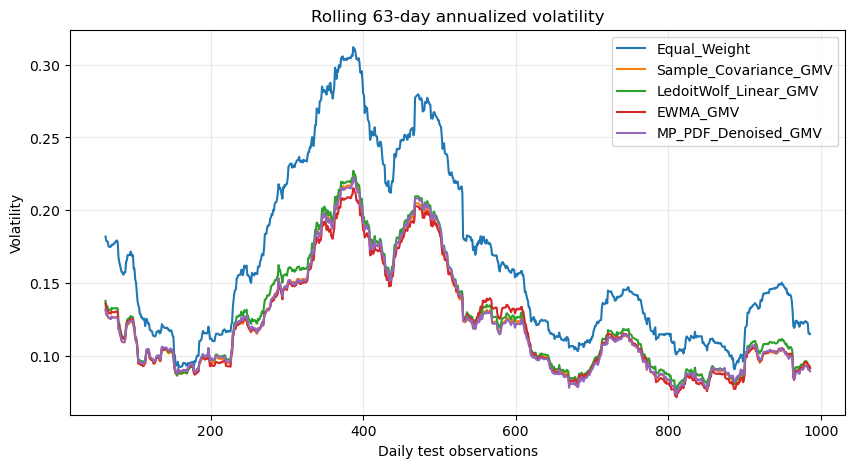

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, bt in test_backtests.items():
    r = pd.Series(bt["gross_returns"])
    rolling_vol = np.sqrt(252) * r.rolling(63).std()
    ax.plot(rolling_vol, label=name)
ax.set_title("Rolling 63-day annualized volatility")
ax.set_xlabel("Daily test observations")
ax.set_ylabel("Volatility")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

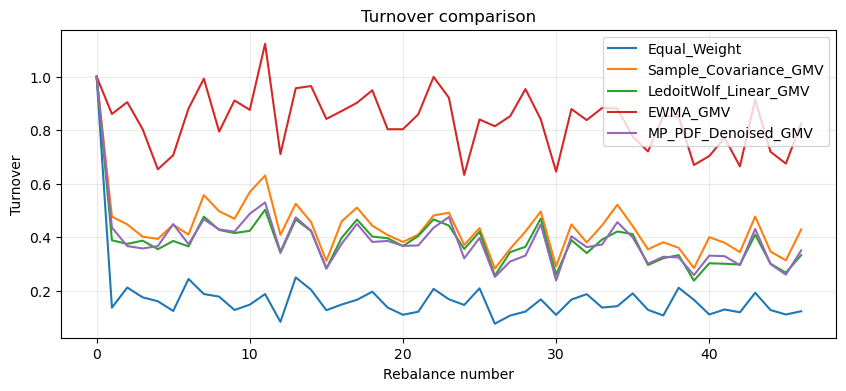

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, bt in test_backtests.items():
    ax.plot([x[1] for x in bt["turnovers"]], label=name)
ax.set_title("Turnover comparison")
ax.set_xlabel("Rebalance number")
ax.set_ylabel("Turnover")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

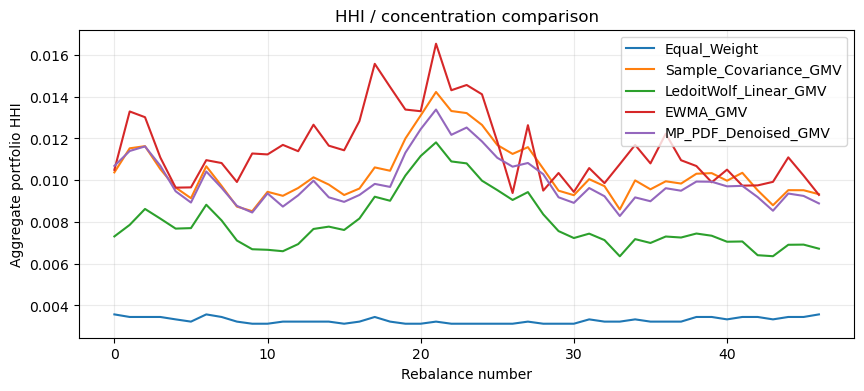

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, bt in test_backtests.items():
    hhi = [np.sum(np.asarray(list(w.values())) ** 2) for _, w in bt["weights"]]
    ax.plot(hhi, label=name)
ax.set_title("HHI / concentration comparison")
ax.set_xlabel("Rebalance number")
ax.set_ylabel("Aggregate portfolio HHI")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

NameError: name 'test_mp_diag' is not defined

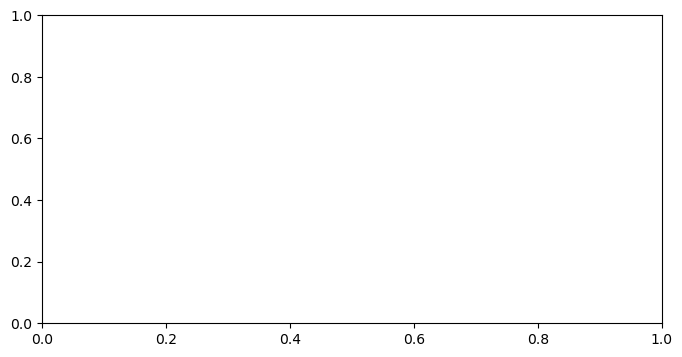

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_mp_diag["max_eigenvalue"], bins=30, alpha=0.75, label="max eigenvalue")
ax.axvline(marchenko_pastur_lambda_plus(Q), color="black", linestyle="--", label="MP lambda_plus")
ax.set_title("Test sleeve correlation max eigenvalues vs MP threshold")
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Sleeve count")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

## Required Checks

In [ ]:
assert np.isclose(Q, 12.6)
assert np.isclose(marchenko_pastur_lambda_plus(Q), (1 + np.sqrt(1 / Q)) ** 2)
for key, data in list(test_sleeve_data.items())[:10]:
    cov_mp = denoise_cov_mp(data["S_hist"], n_obs=LOOKBACK_DAYS)
    assert cov_mp.shape == (10, 10)
    assert np.allclose(cov_mp, cov_mp.T, atol=1e-10)
    assert np.allclose(np.sqrt(np.diag(cov_mp)), np.sqrt(np.diag(data["S_hist"])), atol=1e-10)
for suite_name, suite in [("validation", validation_backtests), ("test", test_backtests)]:
    for method_name, bt in suite.items():
        for _, weights in bt["weights"]:
            assert abs(sum(weights.values()) - 1.0) < 1e-6, (suite_name, method_name)
print("All checks passed.")

## Interpretation

The MP-PDF denoiser is a covariance-estimation benchmark, not a learned model. It should be judged mainly by whether the denoised covariance produces lower realized test volatility than sample covariance GMV and Ledoit-Wolf GMV under the same sleeve construction and holding-period mechanics.

If MP-PDF wins, the result suggests that eigenvalue noise cleaning added useful stability to the 126-day sample covariance for 10-stock sleeves.

If MP-PDF loses, the result suggests that this fixed Marchenko-Pastur threshold and simple average-noise-eigenvalue replacement were not more robust than the conventional covariance estimators in this setting.